# Attribute 9 - Land Stability
#### Rationale:
Protect erosion-prone land; HEL model derived from slope, land cover (from satellite imagery Land Cover Database (LCDB) version 4.0, nominal date 2012/13), rock type. 

#### Data layers
Highly Erodible Land (HEL) model link https://statisticsnz.shinyapps.io/highly_erodible_land/ and background https://www.stats.govt.nz/indicators/highly-erodible-land

#### Scoring
Raster attribute table:

| Value | Class name                                   | Colour      |
|-------|----------------------------------------------|-------------|
| 0     | undefined                                    | White       |
| 1     | land                                         | Light grey  |
| 2     | water                                        | Blue        |
| 3     | watercourse bare ground                      | Dark grey   |
| 4     | high landslide risk – delivery to stream     | Red         |
| 5     | high landslide risk – non delivery to stream | Light brown |
| 6     | moderate earthflow risk                      | Pink        |
| 7     | severe earthflow risk                        | Purple      |
| 8     | gully risk                                   | Gold        |
| 9     | woody vegetation                             | Green       |



In [1]:
import json
import math
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from constants import small_polygon_threshold, m2_to_ha, x_resolution, y_resolution, keep_cols, keep_cols_catch

# Load

In [ ]:
erosion_risk_mapping = {   
    4:10,    #high landslide risk – delivery to stream	Red
    5:8,    #high landslide risk – non delivery to stream	Light brown
    6:6,    #moderate earthflow risk	Pink
    7:4,    #severe earthflow risk	Purple
    8:2,    #gully risk	Gold
}

In [7]:
%%time
erosil = gpd.read_file('../BaseLayersExternal/ero-risk/erorisk_sil_vectorised.gpkg')
erosil.head()
erosil.sindex
erosil.shape[0]

erosil = erosil[erosil.DN.isin(erosion_risk_mapping.keys())].copy().reset_index(drop=True)

erosil['PixelScore'] = erosil.DN.map(erosion_risk_mapping)
erosil = erosil.drop('DN', axis=1).copy()
erosil.to_file('../BaseLayersExternal/ero-risk/erorisk_sil_vectorised_filtered.gpkg')
erosil.sindex

CPU times: total: 1.52 s
Wall time: 1.48 s


In [11]:
%%time
eronil = gpd.read_file('../BaseLayersExternal/ero-risk/erorisk_nil_vectorised.gpkg')
eronil.sindex
eronil.shape[0]
eronil.head()

eronil = eronil[eronil.ERO_Score.isin(erosion_risk_mapping.keys())].copy()

eronil['PixelScore'] = eronil.ERO_Score.map(erosion_risk_mapping)
eronil = eronil.drop('ERO_Score', axis=1).copy().reset_index(drop=True)

eronil.to_file('../BaseLayersExternal/ero-risk/erorisk_nil_vectorised_filtered.gpkg')
eronil.sindex

CPU times: total: 2.77 s
Wall time: 2.75 s


In [29]:
%%time
#area of interest
aoi_path = r'../BaseLayersEco-index/Eco-index_RestorableAreas__Catchments_v290824.gpkg'
aoi = gpd.read_file(aoi_path)
aoi.sindex
aoi.shape

CPU times: total: 844 ms
Wall time: 909 ms


(29431, 5)

In [30]:
aoi.Catchment.value_counts()

Catchment
Clutha                            1403
Waitaki                           1329
Whanganui                         1306
Auckland Basin                    1039
East-Cape                         1010
                                  ... 
Porirua offshore                     6
Far North offshore islands           5
Kāpiti                               4
Whangārei islands                    3
Bay of Plenty offshore islands       1
Name: count, Length: 92, dtype: int64

In [41]:
# erosil = gpd.read_file(r'C:\Users\dav\Documents\EcoIndex\_GIS_CORE\_DAIRYNZ\base_layers\erorisk_sil_vectorised_filtered.gpkg').to_crs('epsg:2193')
# eronil = gpd.read_file(r'C:\Users\dav\Documents\EcoIndex\_GIS_CORE\_DAIRYNZ\base_layers\erorisk_nil_vectorised_filtered.gpkg').to_crs('epsg:2193')

In [15]:
ero = gpd.GeoDataFrame(pd.concat([erosil, eronil], ignore_index=True))

In [17]:
pixel_desc_mapping = {   
    10:'High landslide risk – delivery to stream',
    8:'High landslide risk – non delivery to stream',
    6:'Severe earthflow risk',
    4:'Moderate earthflow risk',
    2:'Gully risk',
}

ero['PixelDesc'] = ero.PixelScore.map(pixel_desc_mapping)
ero = ero[~pd.isna(ero.PixelScore)]

In [18]:
ero.sindex, aoi.sindex

(<geopandas.sindex.SpatialIndex at 0x22ec2c8fc10>,
 <geopandas.sindex.SpatialIndex at 0x22e874f7c10>)

In [28]:
ero.head()

,geometry,PixelScore,PixelDesc
0,"POLYGON ((1573566.234 5516858.717, 1573566.234...",8,High landslide risk – non delivery to stream
1,"POLYGON ((1572906.285 5516843.711, 1572906.285...",8,High landslide risk – non delivery to stream
2,"POLYGON ((1572936.282 5516843.711, 1572936.282...",10,High landslide risk – delivery to stream
3,"POLYGON ((1573251.258 5516903.734, 1573266.257...",8,High landslide risk – non delivery to stream
4,"POLYGON ((1572966.28 5516828.705, 1572966.28 5...",10,High landslide risk – delivery to stream


# Overlay

In [31]:
%%time
# CPU times: total: 1h 16min 44s
# Wall time: 1h 16min 55s

aoi.sindex, ero.sindex
stability_aoi = ero.overlay(aoi[['Catchment', 'geometry']], how='intersection')
# stability_aoi = stability_aoi.dissolve(['Catchment', 'PixelScore', 'PixelDesc']).reset_index().explode()
stability_aoi['PrioOption'] = 'Land Stability'

stability_aoi['Area_ha'] = stability_aoi.area * m2_to_ha
stability_aoi = stability_aoi[stability_aoi.Area_ha > small_polygon_threshold].copy().reset_index(drop=True)
stability_aoi['Area_ha'] = stability_aoi['Area_ha'].round(2)

CPU times: total: 1h 3min 33s
Wall time: 1h 3min 41s


# Plot

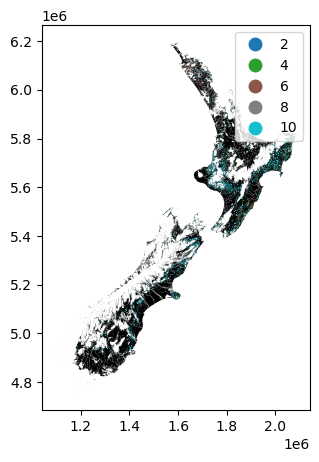

In [20]:
fig, ax = plt.subplots(figsize=(12,5))
aoi.plot(color='black', ax=ax)
stability_aoi.plot(column='PixelScore', ax=ax, legend=True, categorical=True)
plt.show()

# Save

In [32]:
stability_aoi[keep_cols_catch].to_file(f"../OutputArtifacts/A09_LandStability/A09_LandStability_20240829.gpkg")

# Save by Catchment

In [33]:
import time
for n_catch, catch in enumerate(aoi.Catchment.sort_values().unique()):
    start_time = time.time()
    current_time = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(start_time))
    print(f"\n{n_catch}_{catch.upper()}      {current_time}")

    sub_stability_aoi = stability_aoi[stability_aoi['Catchment'] == catch][keep_cols_catch].reset_index(drop=True)

    if sub_stability_aoi.shape[0] > 0:
        base_path = r'..\OutputArtifacts\A09_LandStability\A09_Catchments'
        sub_stability_aoi.to_file(f"{base_path}\{str(n_catch).zfill(3)}_{catch}_LandStability_20240829.gpkg")

    formatted_time_diff = time.strftime("%M:%S", time.gmtime(time.time() - start_time))
    print(f"    {catch} Saved. Elapsed time: {formatted_time_diff}")


0_APARIMA      2024-09-06 17:22:33
    Aparima Saved. Elapsed time: 00:00

1_ASHBURTON-HINDS      2024-09-06 17:22:33
    Ashburton-Hinds Saved. Elapsed time: 00:00

2_AUCKLAND BASIN      2024-09-06 17:22:34
    Auckland Basin Saved. Elapsed time: 00:00

3_AUCKLAND OFFSHORE ISLANDS      2024-09-06 17:22:34
    Auckland offshore islands Saved. Elapsed time: 00:00

4_AWATERE      2024-09-06 17:22:34
    Awatere Saved. Elapsed time: 00:00

5_BANKS PENINSULA      2024-09-06 17:22:34
    Banks Peninsula Saved. Elapsed time: 00:00

6_BAY OF PLENTY OFFSHORE ISLANDS      2024-09-06 17:22:34
    Bay of Plenty offshore islands Saved. Elapsed time: 00:00

7_BLUFF OFFSHORE      2024-09-06 17:22:34
    Bluff offshore Saved. Elapsed time: 00:00

8_BULLER      2024-09-06 17:22:34
    Buller Saved. Elapsed time: 00:00

9_CATLINS      2024-09-06 17:22:34
    Catlins Saved. Elapsed time: 00:00

10_CLARENCE      2024-09-06 17:22:34
    Clarence Saved. Elapsed time: 00:00

11_CLUTHA      2024-09-06 17:22